## Nama: Faiz Iqbal I'tishom
## NIM: 164231059
## Kelas: SD-A1

# Class Activity 2 Data Mining TM5

#### 1. Import Library

In [47]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, auc, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

#### 2. Subset Dataset

In [48]:
df = pd.read_csv('C:/Uner/Semester 4/Data Mining I/Week 5/data wisconsin breast cancer.csv')

#### 3. Exploratory Data Analysis

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [50]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [51]:
df.isna().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

#### 4. Feature Selection

In [52]:
df = df.drop(columns=['id', 'Unnamed: 32'])

In [53]:
X = df.drop(columns=['diagnosis']) 
y = df['diagnosis']

#### 5. Modeling Regresi Logistic

Accuracy Score: 99.42%

===== Performa Model Regresi Logistic =====
Accuracy: 0.9942
AUC-ROC: 0.9991
Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       104
           1       1.00      0.99      0.99        67

    accuracy                           0.99       171
   macro avg       1.00      0.99      0.99       171
weighted avg       0.99      0.99      0.99       171



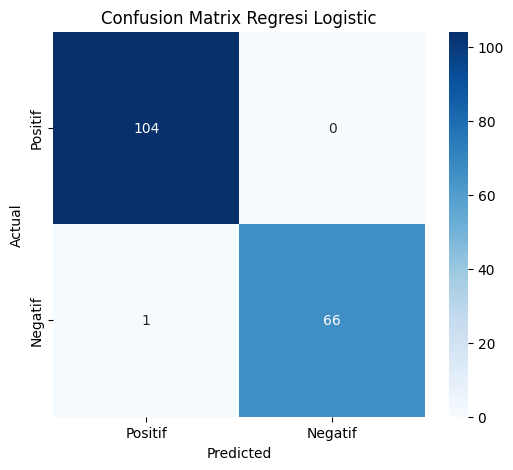

In [54]:
# Mengonversi label menjadi numerik
if y.dtype == 'O':  
    y = y.map({'M': 1, 'B': 0})  
    # M (Malignant) = 1, B (Benign) = 0

# Split data menjadi training dan testing (proporsi: 70% data train dan 30% data test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=29)

# Normalisasi fitur dengan standard scaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Inisialisasi dan latih model Regresi Logistic
model = LogisticRegression()
model.fit(X_train, y_train)

# Memulai Prediksi
y_pred = model.predict(X_test)

# Evaluasi model
cm = confusion_matrix(y_test, y_pred)
acc_logreg = accuracy_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
y_pred_proba = model.predict_proba(X_test)[:, 1]
auc_roc = roc_auc_score(y_test, y_pred_proba)

# Visualisasi hasil
def plot_confusion_matrix(cm, title="Confusion Matrix"):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Positif", "Negatif"], yticklabels=["Positif", "Negatif"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

print(f"Accuracy Score: {acc_logreg * 100:.2f}%")
print("\n===== Performa Model Regresi Logistic =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'AUC-ROC: {auc_roc:.4f}')
print("Classification Report:\n", report)
plot_confusion_matrix(cm, "Confusion Matrix Regresi Logistic")

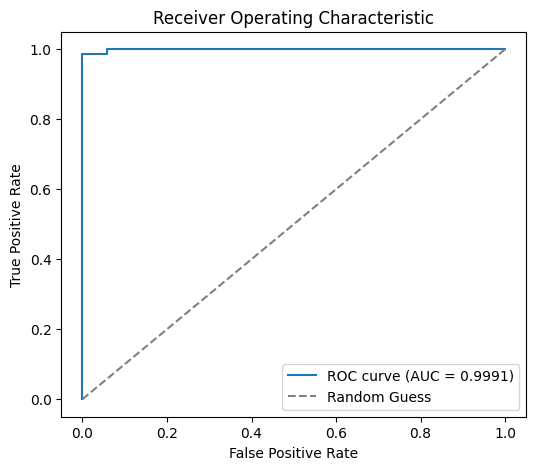

The roc_auc score for the ML model is 0.9991


In [55]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label = "ROC curve (AUC = {:.4f})".format(roc_auc))
plt.plot([0,1], [0,1], linestyle = "--", color = "gray", label = "Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic")
plt.legend(loc = "lower right")
plt.show()
print("The roc_auc score for the ML model is {}".format(round(roc_auc, 4)))

In [56]:
import pandas as pd
df = pd.read_excel("C:/Uner/Semester 4/Data Mining I/Week 6/RSVP.xlsx")

In [57]:
df['Main Course'].value_counts()

Main Course
Bistik Ayam Makasar             22
Nasi Soto Ayam                   8
Nasi Goreng Jawa                 5
Nasi Ayam Bumbu Rujak + Urap     5
Nasi Bali Ayam / Daging          4
Nasi Madura                      3
Soto Daging                      2
Nasi Udang                       2
Nasi Krengsengan                 1
Mie Nyemek                       1
Name: count, dtype: int64

In [58]:
df["Minuman"].value_counts()

Minuman
Lemon Tea    34
Ice Tea      19
Name: count, dtype: int64

## Interpretasi

##### Dengan menggunakan Regresi Logistic, data yang sudah di scaler menghasilkan model yang baik dalam mengklasifikasikan variabel dependen yang kita tuju. Hal ini dapat dilihat pada tungginya skor akurasi pada evaluasi model dan juga skor roc_auc dengan nilai masing-masing 0.9942 dan 0.9991. Selain itu, nilai-nilai pada metrics evaluasi lain seperti recall, f1-score, dan precission dengan nilai yang juga sangat tinggi diangka lebih dari 0.99 untuk setiap metrics. 

##### Visualisasi pada confusion matrix juga menunjukkan indikasi yang positif dengan jumlah total false prediction hanya di angka 1 dari 171 data test yang diprediksi oleh model. Grafik Auc yang ditampilkan juga menunjukkan bahwa model logistik yang digunakan hampir sempurna dalam mengklasifikasikan variabel dependen yang di target oleh model. Kesimpulannya, baik secara metrics statistik maupun visualisasi, model regresi yang digunakan terbukti sangat baik dalam melakukan prediksi klasisfikasi untuk mendiagnosis penyakit kanker payudara.